# Tamara Lane's Notebook - Project 7




- Author: [Tamara Lane](https://github.com/TLane521/)
- Repository: [datafun-04-notebooks](https://github.com/TLane521/datafun-07-applied/)
- Date: 2026-02



## Necessary Imports


In [156]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Pandas display configuration (helps in notebooks)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

print("Imports complete.")

Imports complete.


## Part 1 Chart a Straight Line



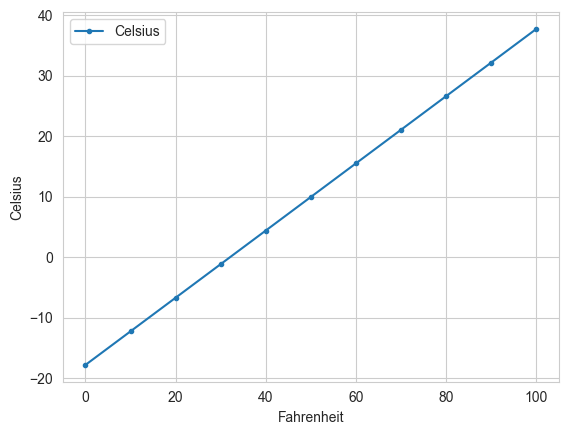

In [157]:
def c(f):  # type: ignore
    return 5 / 9 * (f - 32)


temps = [(f, c(f)) for f in range(0, 101, 10)]
import pandas as pd  # noqa: E402

temps_df = pd.DataFrame(temps, columns=['Fahrenheit', 'Celsius'])
axes = temps_df.plot(x='Fahrenheit', y='Celsius', style='.-')
y_label = axes.set_ylabel('Celsius')

## Part 2 NYC Predictions

In [158]:
nyc = pd.read_csv('../data/raw/ave_hi_nyc_jan_1895-2018.csv')
nyc.head()
nyc.tail()

,Date,Value,Anomaly
119,201401,35.5,-1.9
120,201501,36.1,-1.3
121,201601,40.8,3.4
122,201701,42.8,5.4
123,201801,38.7,1.3


### Data Clean Up

In [159]:
nyc = pd.read_csv('../data/raw/ave_hi_nyc_jan_1895-2018.csv')

nyc.columns = ['Date', 'Temperature', 'Anomaly']
nyc.head(3)
nyc.Date.dtype  # noqa: B018
nyc.Date = nyc.Date.floordiv(100)  # type: ignore
nyc.head(3)

,Date,Temperature,Anomaly
0,1895,34.2,-3.2
1,1896,34.7,-2.7
2,1897,35.5,-1.9


## New York City Chart from 10.16



(10.0, 70.0)

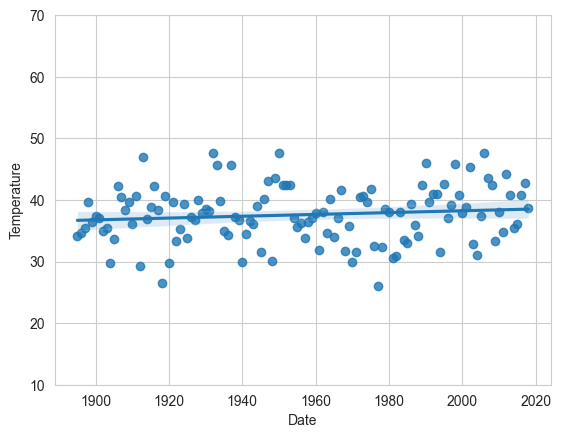

In [160]:
nyc = pd.read_csv('../data/raw/ave_hi_nyc_jan_1895-2018.csv')
nyc.head()
nyc.tail()
nyc.columns = ['Date', 'Temperature', 'Anomaly']
nyc.head(3)
nyc.Date.dtype  # noqa: B018
nyc.Date = nyc.Date.floordiv(100)  # type: ignore
nyc.head(3)
pd.set_option('display.precision', 2)
from scipy import stats  # type: ignore # noqa: E402

linear_regression = stats.linregress(x=nyc.Date, y=nyc.Temperature)
linear_regression.slope  # noqa: B018
linear_regression.intercept  # noqa: B018
linear_regression.slope * 2019 + linear_regression.intercept  # type: ignore
linear_regression.slope * 1890 + linear_regression.intercept  # type: ignore

sns.set_style('whitegrid')
axes = sns.regplot(x=nyc.Date, y=nyc.Temperature)
axes.set_ylim(10, 70)

## 2024 Prediction

In [161]:
# Predict the average high temperature in January for 2024
pred_2024 = linear_regression.slope * 2024 + linear_regression.intercept

print(f"Predicted average high temperature in January 2024: {pred_2024:.2f}")

Predicted average high temperature in January 2024: 38.59


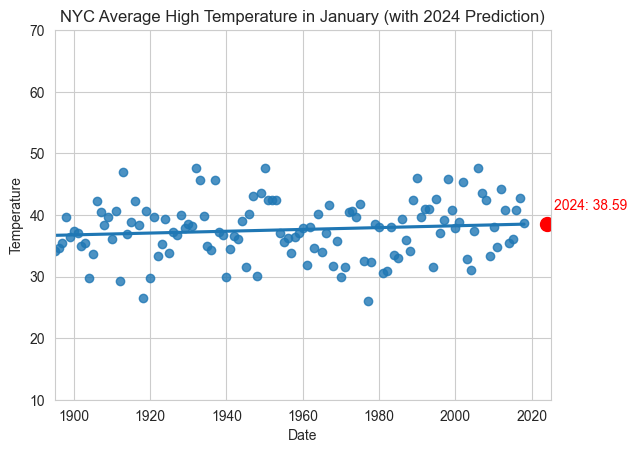

In [162]:
sns.set_style('whitegrid')

# Create the base scatter + regression line (no CI band)
axes = sns.regplot(x=nyc.Date, y=nyc.Temperature, ci=None)

# Calculate predicted 2024 value
pred_2024 = linear_regression.slope * 2024 + linear_regression.intercept

# Add the predicted 2024 point
axes.scatter(2024, pred_2024, color='red', s=100)

# Add annotation
axes.annotate(
    f"2024: {pred_2024:.2f}",
    (2024, pred_2024),
    textcoords="offset points",
    xytext=(5, 10),
    ha='left',
    color='red',
)

# Extend x-axis to include 2024
axes.set_xlim(nyc.Date.min(), 2025)

# Keep required y-axis scale
axes.set_ylim(10, 70)

axes.set_xlabel('Date')
axes.set_ylabel('Temperature')
axes.set_title('NYC Average High Temperature in January (with 2024 Prediction)')

plt.show()

## Part 3 - Prediction



### Section 1 - Build the Model

In [174]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [175]:
X = nyc[['Date']]
y = nyc['Temperature']

In [176]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=11
)

In [177]:
X_train.shape  # noqa: B018
X_test.shape  # noqa: B018
y_train.shape  # noqa: B018
y_test.shape

(25,)

In [178]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [179]:
m = linear_model.coef_[0]
b = linear_model.intercept_

print("Slope:", m)
print("Intercept:", b)

Slope: 0.014710558995821564
Intercept: 8.891970558021107


### Section 2 - Test the Model

In [180]:
test_score = linear_model.score(X_test, y_test)
print("Model R^2 score on test data:", test_score)

Model R^2 score on test data: 0.0032988738704902154


### Section 3 - Predict

In [181]:
pred_2024 = linear_model.predict([[2024]])
print("Predicted January average high in 2024:", pred_2024[0])

Predicted January average high in 2024: 38.66614196556395


c:\Repos\datafun-07-applied\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


### Section 4 - Visualizations

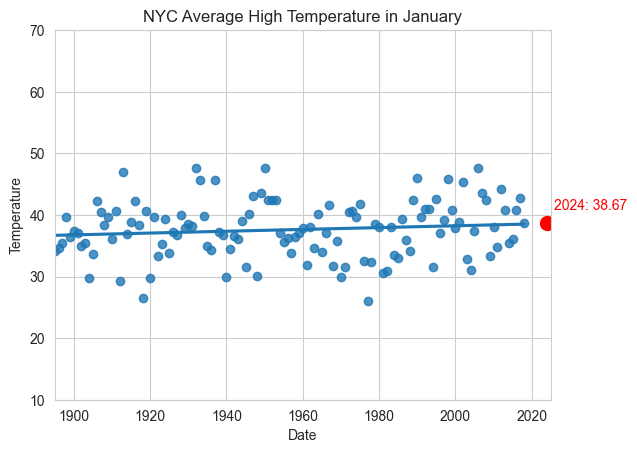

In [182]:
sns.set_style('whitegrid')

# Scatter + best fit line
axes = sns.regplot(x=nyc.Date, y=nyc.Temperature, ci=None)

# Add 2024 predicted point
axes.scatter(2024, pred_2024[0], color='red', s=100)

axes.annotate(
    f"2024: {pred_2024[0]:.2f}",
    (2024, pred_2024[0]),
    textcoords="offset points",
    xytext=(5, 10),
    color='red',
)

axes.set_xlim(nyc.Date.min(), 2025)
axes.set_ylim(10, 70)

axes.set_xlabel('Date')
axes.set_ylabel('Temperature')
axes.set_title('NYC Average High Temperature in January')

plt.show()